# California housing price prediction

In [21]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [22]:
# dir(datasets) #to check all the datasets

In [23]:
# Data preparation
data = fetch_california_housing()
print(data.DESCR) # To get the description of data

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [24]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df[data.target_names[0]] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# EDA

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [26]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [27]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<Axes: >

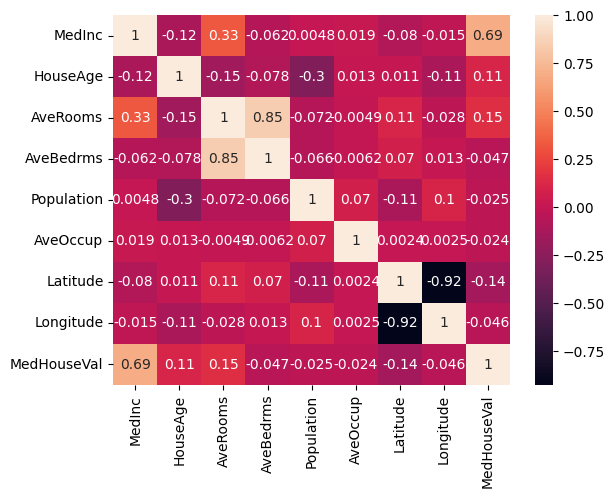

In [28]:
sns.heatmap(df.corr(), annot=True)

# Model Training

In [29]:
# Divide the data into input and output
X = df.drop('MedHouseVal',axis=1)
y = df['MedHouseVal']

In [30]:
# ML rules --> 100% --> 70%(training), 30%(testing)
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [31]:
# Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Xtrain = sc.fit_transform(Xtrain) # fit -> scaled details will be leaked to the model for learning
Xtest = sc.transform(Xtest) # only transform -> to avoid data leakage

In [32]:
# model training
model = LinearRegression()
model.fit(Xtrain,ytrain)

LinearRegression()

In [33]:
print("Intercept: ",model.intercept_)
print("Slope: ",model.coef_) # we get slope for each and every input column

Intercept:  2.0692396089424165
Slope:  [ 8.49221760e-01  1.22119309e-01 -2.99558449e-01  3.48409673e-01
 -8.84488134e-04 -4.16980388e-02 -8.93855649e-01 -8.68616688e-01]


# Model prediction

In [34]:
ypred=model.predict(Xtest)
ypred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

# Model Evaluation

In [35]:
print("Metrics: ")
r2 = r2_score(ytest,ypred)
print("R2: ",r2)
N=df.shape[0]
P=df.shape[1]
adj_r2 = 1-(((1-r2**2)*(N-1))/N-P-1)
print("adj R2: ",adj_r2)
print("MSE: ",mean_squared_error(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))

Metrics: 
R2:  0.5957702326061664
adj R2:  10.354973422861445
MSE:  0.5305677824766752
MAE:  0.5272474538305955


## BIAS: It is an error which is calculated using training data
## VARIANCE: It is an error which is calculated using testing data

In [36]:
# Training      Testing     bias      variance
# high           high        low        low      --> Generalized model
# high           low         low        high     --> Overfitting problem
# low            low         high       high     --> Underfitting problem

# Generalized model -> when a model is working well for both training dataset and testing dataset or when we have low bias and low variance
# Overfitting problem -> when a model is working well for training dataset but not for testing dataset or when we have low bias and high variance
# Underfitting problem -> when a model is not working well for both training dataset and for testing dataset or when we have high bias and high variance

In [37]:
print("Training Eff: ",model.score(Xtrain,ytrain))
print("Testing Eff: ",model.score(Xtest,ytest))
# underfitting problem

Training Eff:  0.6093459727972159
Testing Eff:  0.5957702326061664


In [38]:
new_data = df.iloc[:1,:-1]
pred = model.predict(new_data)[0]
print("Predicted Price : $",pred*100000)

Predicted Price : $ 8433102.211532095


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


# Car price prediction

In [39]:
df = pd.read_csv("/content/car_price_prediction.csv")
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [40]:
df.isnull().sum()

,0
ID,0
Price,0
Levy,0
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,0


In [41]:
df.drop_duplicates(inplace=True)
df.shape

(18924, 18)

In [42]:
df = df.drop(["ID","Doors"],axis=1)
df

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,Left wheel,Silver,5
19233,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,Left wheel,Red,8
19234,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,Left wheel,Grey,4
19235,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,Left wheel,Black,4


In [43]:
df["Levy"]=df["Levy"].replace("-",np.nan)
df["Levy"]=df["Levy"].astype(float)
df["Levy"]=df["Levy"].fillna(df["Levy"].mean().round(2))
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,Left wheel,Silver,12
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,Left wheel,Black,8
2,8467,906.3,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,Right-hand drive,Black,2
3,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,Left wheel,White,0
4,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,Left wheel,Silver,4


In [44]:
df["Engine volume"]=df["Engine volume"].str.strip("Turbo")
df["Engine volume"]=df["Engine volume"].astype(float)
df["Engine volume"].unique()

array([ 3.5,  3. ,  1.3,  2.5,  2. ,  1.8,  2.4,  4. ,  1.6,  3.3,  2.2,
        4.7,  1.5,  4.4,  1.4,  3.6,  2.3,  5.5,  2.8,  3.2,  3.8,  4.6,
        1.2,  5. ,  1.7,  2.9,  0.5,  1.9,  2.7,  4.8,  5.3,  0.4,  1.1,
        2.1,  0.7,  5.4,  3.7,  1. ,  2.6,  0.8,  0.2,  5.7,  6.7,  6.2,
        3.4,  6.3,  4.3,  4.2,  0. , 20. ,  0.3,  5.9,  5.6,  6. ,  0.6,
        6.8,  4.5,  7.3,  0.1,  3.1,  6.4,  3.9,  0.9,  5.2,  5.8])

In [45]:
df["Mileage"]=df["Mileage"].str.strip("km")
df["Mileage"]=df["Mileage"].astype(float)
df["Mileage"].unique()

array([186005., 192000., 200000., ..., 140607., 307325., 186923.])

In [46]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Wheel,Color,Airbags
0,13328,1399.0,32,1242,2010,4,1,2,3.5,186005.0,6.0,0,0,0,12,12
1,16621,1018.0,8,658,2011,4,0,5,3.0,192000.0,6.0,2,0,0,1,8
2,8467,906.3,21,684,2006,3,0,5,1.3,200000.0,4.0,3,1,1,1,2
3,3607,862.0,16,661,2011,4,1,2,2.5,168966.0,4.0,0,0,0,14,0
4,11726,446.0,21,684,2014,3,1,5,1.3,91901.0,4.0,0,1,0,12,4


<Axes: >

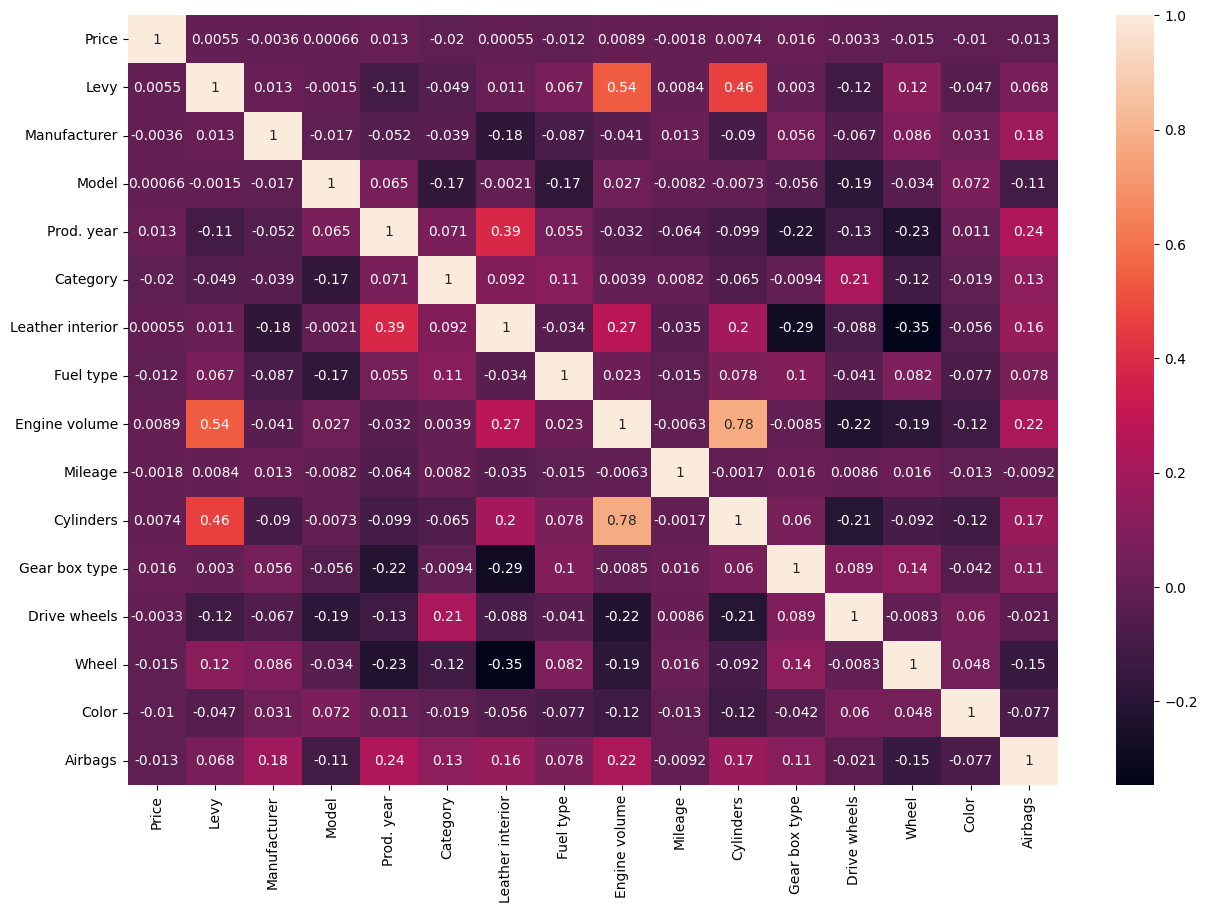

In [57]:
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(),annot=True)

In [48]:
X = df.drop("Price",axis=1)
y = df["Price"]

In [49]:
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [50]:
sc = StandardScaler()
Xtrain = sc.fit_transform(Xtrain)
Xtest = sc.transform(Xtest)

In [51]:
model = LinearRegression()
model.fit(Xtrain,ytrain)

LinearRegression()

In [52]:
ypred = model.predict(Xtest)
ypred

array([ 8469.02118592,  -354.13732874, 14923.33642325, ...,
       24187.39693448, 10037.33819762, 18285.64473419])

In [53]:
print("Training Eff: ",model.score(Xtrain,ytrain))
print("Testing Eff: ",model.score(Xtest,ytest))

Training Eff:  0.0019585686748558873
Testing Eff:  -0.013660998632446075


In [54]:
print("Metrics: ")
r2 = r2_score(ytest,ypred)
print("R2: ",r2)
N=df.shape[0]
P=df.shape[1]
adj_r2 = 1-(((1-r2**2)*(N-1))/N-P-1)
print("adj R2: ",adj_r2)
print("MSE: ",mean_squared_error(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))

Metrics: 
R2:  -0.013660998632446075
adj R2:  17.000239455972682
MSE:  330691183.77421206
MAE:  12794.75187327366
